In [1]:
# As a first step, we import the core libraries needed to explore a NILMTK-style HDF5 file.
# PyTables (`tables`) is essential here because this dataset is not a simple Pandas HDFStore.
# NILMTK uses hierarchical groups and compressed table nodes, so PyTables gives us the
# low-level access required to inspect the file structure and metadata.

import tables

# Pandas will be used to load individual meter tables into DataFrames for inspection.
# Even though the raw data is stored in PyTables, Pandas provides a convenient interface
# for sampling, timestamp conversion, and quick exploratory analysis.

import pandas as pd

# NumPy is included for numerical utilities and type handling. We won't use it heavily
# in this notebook, but it's standard practice to have it available for array operations.

import numpy as np

# Pathlib gives us OS-agnostic path handling. This is preferable to raw strings because
# it avoids issues with slashes and makes the code more portable.

from pathlib import Path

# Matplotlib is used for quick visual sanity checks. Plotting a small slice of raw data
# is one of the fastest ways to confirm that the dataset is behaving as expected.

import matplotlib.pyplot as plt


In [2]:
# Here we define the path to the HDF5 dataset. Using Path() ensures compatibility across
# operating systems and avoids common string path issues.

h5_path = Path("../data/raw/ukdale.h5")

# We open the file in read-only mode. This is important: exploration should never mutate
# the dataset. PyTables gives us a handle (`h5`) that exposes the full hierarchical structure.

h5 = tables.open_file(h5_path, mode="r")

# Printing the file object triggers PyTables' built-in tree printer. This is the canonical
# way to inspect a NILMTK HDF5 file. It reveals:
# - all buildings
# - all meters
# - all table nodes
# - row counts
# - compression details
#
# This step is foundational. You never trust assumptions about a dataset until you inspect
# the actual file structure.

print(h5)


..\data\raw\ukdale.h5 (File) ''
Last modif.: '2026-01-25T23:56:51+00:00'
Object Tree: 
/ (RootGroup) ''
/building1 (Group) ''
/building2 (Group) ''
/building3 (Group) ''
/building4 (Group) ''
/building5 (Group) ''
/building5/elec (Group) ''
/building5/elec/meter1 (Group) ''
/building5/elec/meter1/table (Table(np.int64(1763101),)shuffle, blosc(9)) ''
/building5/elec/meter10 (Group) ''
/building5/elec/meter10/table (Table(np.int64(985784),)shuffle, blosc(9)) ''
/building5/elec/meter11 (Group) ''
/building5/elec/meter11/table (Table(np.int64(10215),)shuffle, blosc(9)) ''
/building5/elec/meter12 (Group) ''
/building5/elec/meter12/table (Table(np.int64(985779),)shuffle, blosc(9)) ''
/building5/elec/meter13 (Group) ''
/building5/elec/meter13/table (Table(np.int64(985600),)shuffle, blosc(9)) ''
/building5/elec/meter14 (Group) ''
/building5/elec/meter14/table (Table(np.int64(985998),)shuffle, blosc(9)) ''
/building5/elec/meter15 (Group) ''
/building5/elec/meter15/table (Table(np.int64(985856),

In [3]:
# We now build a programmatic inventory of the dataset. This is far more reliable than
# relying on documentation or assumptions, because NILMTK HDF5 files can vary depending
# on how they were generated.

buildings = {}

# PyTables exposes child groups via `_v_groups`. We iterate over the root-level groups
# and select only those whose names begin with "building". This avoids picking up any
# internal metadata groups that PyTables may create.

for b in h5.root._v_groups:
    if b.startswith("building"):
        
        # For each building, we descend into the /buildingX/elec group and list all meter groups.
        # This gives us a complete, verified list of meters per building.
        meters = list(h5.get_node(f"/{b}/elec")._v_groups.keys())
        
        buildings[b] = meters

# Display the resulting dictionary. This gives us a clear overview of how many meters
# each building contains. This is essential for downstream processing and documentation.

buildings


{'building1': ['meter1',
  'meter10',
  'meter11',
  'meter12',
  'meter13',
  'meter14',
  'meter15',
  'meter16',
  'meter17',
  'meter18',
  'meter19',
  'meter2',
  'meter20',
  'meter21',
  'meter22',
  'meter23',
  'meter24',
  'meter25',
  'meter26',
  'meter27',
  'meter28',
  'meter29',
  'meter3',
  'meter30',
  'meter31',
  'meter32',
  'meter33',
  'meter34',
  'meter35',
  'meter36',
  'meter37',
  'meter38',
  'meter39',
  'meter4',
  'meter40',
  'meter41',
  'meter42',
  'meter43',
  'meter44',
  'meter45',
  'meter46',
  'meter47',
  'meter48',
  'meter49',
  'meter5',
  'meter50',
  'meter51',
  'meter52',
  'meter53',
  'meter54',
  'meter6',
  'meter7',
  'meter8',
  'meter9'],
 'building2': ['meter1',
  'meter10',
  'meter11',
  'meter12',
  'meter13',
  'meter14',
  'meter15',
  'meter16',
  'meter17',
  'meter18',
  'meter19',
  'meter2',
  'meter20',
  'meter3',
  'meter4',
  'meter5',
  'meter6',
  'meter7',
  'meter8',
  'meter9'],
 'building3': ['meter1', 'me

In [4]:
# This helper function inspects a specific meter. It prints:
# - the HDF5 path
# - the number of rows
# - the column names
# - the dtype of each column
#
# It also loads a small sample of the data using Pandas. This is a critical step because
# it verifies that the table schema is consistent and that the data is readable.

def inspect_meter(building, meter):
    path = f"/{building}/elec/{meter}/table"
    
    # Retrieve the PyTables node for this meter.
    node = h5.get_node(path)
    
    print("Path:", path)
    print("Rows:", node.nrows)
    print("Columns:", node.colnames)
    print("Dtype:", node.dtype)
    
    # Load the first 5 rows using Pandas. This confirms:
    # - the timestamp format (nanoseconds)
    # - the power column name
    # - that the table is readable and not corrupted
    df = pd.read_hdf(h5_path, path, start=0, stop=5)
    
    print("\nSample:")
    print(df)
    
    return node


In [5]:
# We now inspect the mains meter for Building 1.
# In UK-DALE, meter1 is conventionally the mains feed.
# This gives us a representative view of the dataset's structure and scale.

inspect_meter("building1", "meter1")


Path: /building1/elec/meter1/table
Rows: 21837636
Columns: ['index', 'values_block_0']
Dtype: [('index', '<i8'), ('values_block_0', '<f4', (1,))]

Sample:
                 index  values_block_0
0  1352500095000000000           599.0
1  1352500101000000000           582.0
2  1352500107000000000           600.0
3  1352500113000000000           586.0
4  1352500120000000000           596.0


/building1/elec/meter1/table (Table(np.int64(21837636),)shuffle, blosc(9)) ''
  description := {
  "index": Int64Col(shape=(), dflt=np.int64(0), pos=0),
  "values_block_0": Float32Col(shape=(np.int64(1),), dflt=np.float32(0.0), pos=1)}
  byteorder := 'little'
  chunkshape := (np.int64(21845),)
  autoindex := True
  colindexes := {
    "index": Index(9, fullshuffle, zlib(1)).is_csi=True}

In [6]:
# This function computes the sampling interval for a given meter.
# NILMTK datasets often have irregularities, so we compute both:
# - the mode (most common interval)
# - the median (robust to outliers)
#
# This helps us confirm whether the meter is sampled at 1 second, 6 seconds,
# or some other interval.

def sampling_interval(building, meter, n=50000):
    path = f"/{building}/elec/{meter}/table"
    
    # Load a subset of the data for efficiency. 50k rows is enough to compute
    # a reliable sampling interval without consuming excessive memory.
    df = pd.read_hdf(h5_path, path, stop=n)
    
    # Rename the timestamp column for clarity.
    df = df.rename(columns={"index": "timestamp"})
    
    # Convert nanosecond timestamps to pandas datetime.
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ns")
    
    # Set the timestamp as the index to make diff() operations straightforward.
    df = df.set_index("timestamp")
    
    # Compute differences between consecutive timestamps.
    diffs = df.index.to_series().diff().dropna()
    
    # Return both the mode and median sampling intervals.
    return diffs.mode().iloc[0], diffs.median()


In [7]:
# We now compute the sampling interval for building1/meter1.
# This is a sanity check that confirms the expected 6-second sampling rate.

mode, median = sampling_interval("building1", "meter1")
print("Mode:", mode)
print("Median:", median)


Mode: 0 days 00:00:06
Median: 0 days 00:00:06


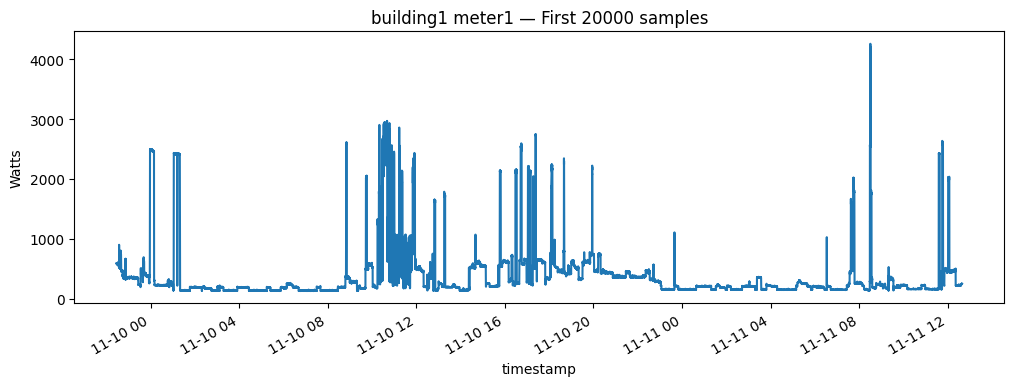

In [8]:
# This function plots the first N samples of a meter.
# Visual inspection is one of the fastest ways to confirm:
# - the data is non-zero
# - the signal looks like real household power usage
# - there are no obvious corruption issues

def plot_meter(building, meter, n=20000):
    path = f"/{building}/elec/{meter}/table"
    
    # Load a slice of the data.
    df = pd.read_hdf(h5_path, path, stop=n)
    
    # Rename columns for clarity.
    df = df.rename(columns={"index": "timestamp", "values_block_0": "power_watts"})
    
    # Convert timestamps.
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ns")
    
    # Set timestamp as index.
    df = df.set_index("timestamp")
    
    # Plot the raw power signal.
    df["power_watts"].plot(figsize=(12,4))
    plt.title(f"{building} {meter} — First {n} samples")
    plt.ylabel("Watts")
    plt.show()

# Plot mains for building 1.
plot_meter("building1", "meter1")


In [9]:
# This block programmatically summarizes the entire dataset.
# For each building and each meter, we record:
# - number of rows
# - column names
#
# This summary is essential for building a complete data dictionary and
# understanding the scale of the dataset.

summary = {}

for b, meters in buildings.items():
    summary[b] = {}
    
    for m in meters:
        path = f"/{b}/elec/{m}/table"
        
        # Retrieve the PyTables node.
        node = h5.get_node(path)
        
        # Store row count and column names.
        summary[b][m] = {
            "rows": node.nrows,
            "columns": node.colnames,
        }

# Display the full summary dictionary.
summary


{'building1': {'meter1': {'rows': np.int64(21837636),
   'columns': ['index', 'values_block_0']},
  'meter10': {'rows': np.int64(18881051),
   'columns': ['index', 'values_block_0']},
  'meter11': {'rows': np.int64(19404267),
   'columns': ['index', 'values_block_0']},
  'meter12': {'rows': np.int64(19381298),
   'columns': ['index', 'values_block_0']},
  'meter13': {'rows': np.int64(19406625),
   'columns': ['index', 'values_block_0']},
  'meter14': {'rows': np.int64(4143648),
   'columns': ['index', 'values_block_0']},
  'meter15': {'rows': np.int64(4157704),
   'columns': ['index', 'values_block_0']},
  'meter16': {'rows': np.int64(13351860),
   'columns': ['index', 'values_block_0']},
  'meter17': {'rows': np.int64(19547699),
   'columns': ['index', 'values_block_0']},
  'meter18': {'rows': np.int64(19116542),
   'columns': ['index', 'values_block_0']},
  'meter19': {'rows': np.int64(18609054),
   'columns': ['index', 'values_block_0']},
  'meter2': {'rows': np.int64(21281331),
   

UK-DALE HDF5 Structure
======================

/
├── building1
│   └── elec
│       ├── meter1
│       │   └── table
│       ├── meter2
│       │   └── table
│       ├── meter3
│       │   └── table
│       ├── ...
│       └── meter54
│           └── table
│
├── building2
│   └── elec
│       ├── meter1
│       │   └── table
│       ├── meter2
│       │   └── table
│       ├── ...
│       └── meter20
│           └── table
│
├── building3
│   └── elec
│       ├── meter1
│       │   └── table
│       ├── ...
│       └── meter5
│           └── table
│
├── building4
│   └── elec
│       ├── meter1
│       │   └── table
│       ├── ...
│       └── meter6
│           └── table
│
└── building5
    └── elec
        ├── meter1
        │   └── table
        ├── meter2
        │   └── table
        ├── ...
        └── meter26
            └── table
